# 1. Imports and setup

In [33]:
import os
import warnings

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# 2. Download and load raw Instacart tables

In [34]:
path = kagglehub.dataset_download(
    "yasserh/instacart-online-grocery-basket-analysis-dataset"
)
print("Dataset downloaded to:", path)
BASE_PATH = path

print("\nFiles in dataset directory:")
for f in os.listdir(BASE_PATH):
    print(f)

orders = pd.read_csv(os.path.join(BASE_PATH, "orders.csv"))
prior = pd.read_csv(os.path.join(BASE_PATH, "order_products__prior.csv"))
train_op = pd.read_csv(os.path.join(BASE_PATH, "order_products__train.csv"))
products = pd.read_csv(os.path.join(BASE_PATH, "products.csv"))
aisles = pd.read_csv(os.path.join(BASE_PATH, "aisles.csv"))
departments = pd.read_csv(os.path.join(BASE_PATH, "departments.csv"))

Dataset downloaded to: /Users/bettinabopeng/.cache/kagglehub/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/versions/1

Files in dataset directory:
products.csv
orders.csv
order_products__train.csv
departments.csv
aisles.csv
order_products__prior.csv


In [35]:
print(orders.head())
print(prior.head())
print(train_op.head())
print(products.head())
print(aisles.head())
print(departments.head())
print(orders.describe())
print(prior.describe())
print(train_op.describe())

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0
   order_id  product_id  add_to_cart_order  r

# 3. Original Kaggle split inspection (orders / users / purchase rows)

In [36]:
# 3.1 Order-level share by original eval_set
order_counts = orders["eval_set"].value_counts(dropna=False)
print("\nOrders by eval_set:")
print(order_counts)
print("\nOrders share:")
print((order_counts / len(orders)).round(4))

#
# 3.2 User-level share by final eval_set
user_eval = orders.groupby("user_id")["eval_set"].agg(lambda s: set(s)).reset_index()

# In the standard Instacart setup, a user's final order determines whether the user belongs to train or test.
# We identify this robustly by taking each user's last order.
last_order = orders.sort_values(["user_id", "order_number"]).groupby("user_id").tail(1)
user_counts = last_order["eval_set"].value_counts()
print("\nUsers by final eval_set (based on last order):")
print(user_counts)
print("\nUsers share:")
print((user_counts / user_counts.sum()).round(4))

# 3.3 Purchase-row contribution: how many prior rows come from train users vs test users
test_users = set(last_order.loc[last_order["eval_set"] == "test", "user_id"])
train_users = set(last_order.loc[last_order["eval_set"] == "train", "user_id"])

# Attach user_id to prior rows through orders.csv
prior_u = prior.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
prior_u = prior_u.dropna(subset=["user_id"])
prior_u["user_id"] = prior_u["user_id"].astype(int)

prior_test_rows = (prior_u["user_id"].isin(test_users)).sum()
prior_train_rows = (prior_u["user_id"].isin(train_users)).sum()

print("\nPrior rows share by user group:")
print("  prior total rows:", len(prior_u))
print("  prior rows from train users:", prior_train_rows, f"({prior_train_rows/len(prior_u):.4%})")
print("  prior rows from test users :", prior_test_rows,  f"({prior_test_rows/len(prior_u):.4%})")

# Do the same for train order-products rows (these should correspond to train users)
train_u = train_op.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
print("\nTrain order_products rows:", len(train_u))
print("Unique users in train_op:", train_u['user_id'].nunique())



Orders by eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Orders share:
eval_set
prior    0.9397
train    0.0384
test     0.0219
Name: count, dtype: float64

Users by final eval_set (based on last order):
eval_set
train    131209
test      75000
Name: count, dtype: int64

Users share:
eval_set
train    0.6363
test     0.3637
Name: count, dtype: float64

Prior rows share by user group:
  prior total rows: 32434489
  prior rows from train users: 20641991 (63.6421%)
  prior rows from test users : 11792498 (36.3579%)

Train order_products rows: 1384617
Unique users in train_op: 131209


# 4. Utility helper for quick distribution plots

In [37]:
def plot_hist_with_quantiles(series: pd.Series, title: str, xlabel: str, bins: int = 80, logy: bool = True):
    s = pd.Series(series).dropna().astype(float)
    qs = s.quantile([0.50, 0.90, 0.99]).to_dict()

    print(f"\n{title}")
    print("  count:", int(s.shape[0]))
    print("  quantiles:", {k: float(v) for k, v in qs.items()})

    plt.figure(figsize=(9, 4))
    plt.hist(s.values, bins=bins)
    if logy:
        plt.yscale("log")

    ymax = plt.ylim()[1]
    for p in [0.50, 0.90, 0.99]:
        v = qs[p]
        plt.axvline(v, linestyle="--")
        plt.text(v, ymax * 0.85, f"p{int(p*100)}", rotation=90, va="top")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    return qs

# 5. Build a unified purchase-level table (prior + train)

In [38]:
# Important note:
# Public Instacart data does not include product-level rows for test users' final test order.
# Therefore, when we later define a per-user target order, we use the last AVAILABLE order
# that has product details in the unified purchase table.

op_all = pd.concat(
    [prior.assign(source="prior"), train_op.assign(source="train")],
    ignore_index=True,
)

# Attach user/order metadata to each purchased row
op_all = op_all.merge(
    orders[["order_id", "user_id", "order_number", "eval_set"]],
    on="order_id",
    how="left",
)

# Attach product hierarchy metadata from the beginning
# This keeps the unified purchase table aligned with downstream EDA and future modeling.
op_all = op_all.merge(
    products[["product_id", "aisle_id", "department_id"]],
    on="product_id",
    how="left",
)
op_all = op_all.merge(
    aisles[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left",
)
op_all = op_all.merge(
    departments[["department_id", "department"]],
    on="department_id",
    how="left",
)

op_all = op_all.dropna(subset=["user_id"]).copy()
op_all["user_id"] = op_all["user_id"].astype(np.uint32)

# Missing-value diagnostics (merged op_all)
## -----------------------------------------------------
print("\nMissing-value check (merged op_all):")
key_cols = [
    "order_id", "product_id", "user_id", "order_number", "eval_set",
    "aisle_id", "department_id", "aisle", "department",
]
missing_key = op_all[key_cols].isna().sum()
print(missing_key.to_string())

# Sanity check: user_id should be fully present after dropna
print("  user_id missing after dropna:", int(op_all["user_id"].isna().sum()))


## -----------------------------------------------------
# 5.1 Preview of the fully merged purchase-level table
# Each row in op_all is one purchased product within one order.
# Columns:
#   order_id                : unique order identifier
#   product_id              : purchased product identifier
#   add_to_cart_order       : position of the product within the cart/order
#   reordered               : 1 if this product had been purchased by the same user before, else 0
#   source                  : whether this purchase row originally came from the Kaggle prior set or train set
#   user_id                 : unique user identifier
#   order_number            : sequential order index for that user (1 = first order)
#   eval_set                : original Kaggle split label of the order (prior / train / test)
#   aisle_id                : aisle/category identifier from products.csv
#   department_id           : department identifier from products.csv
#   aisle                   : aisle name
#   department              : department name
#
# Note:
#   - op_all is our unified purchase table built by concatenating prior and train purchase records,
#     then attaching both user/order metadata and product hierarchy metadata.
#   - test orders do not have public product-level rows, so eval_set == 'test' does not appear as
#     purchased rows in op_all.
## -----------------------------------------------------
print("\nHead of merged purchase-level table op_all:")
print(op_all.head(10).to_string(index=False))

## -----------------------------------------------------
# 5.2 Coverage check after merging raw purchase tables
## -----------------------------------------------------
print("\nUnified scope (ALL users):")
print("  orders:", orders.shape)
print("  op_all (prior+train purchases):", op_all.shape)
print("  unique users in orders:", orders["user_id"].nunique())
print("  unique users with purchases in op_all:", op_all["user_id"].nunique())


Missing-value check (merged op_all):
order_id         0
product_id       0
user_id          0
order_number     0
eval_set         0
aisle_id         0
department_id    0
aisle            0
department       0
  user_id missing after dropna: 0

Head of merged purchase-level table op_all:
 order_id  product_id  add_to_cart_order  reordered source  user_id  order_number eval_set  aisle_id  department_id                      aisle department
        2       33120                  1          1  prior   202279             3    prior        86             16                       eggs dairy eggs
        2       28985                  2          1  prior   202279             3    prior        83              4           fresh vegetables    produce
        2        9327                  3          0  prior   202279             3    prior       104             13          spices seasonings     pantry
        2       45918                  4          1  prior   202279             3    prior      

# 6. User-order-count inspection and current filtering choice


Per-user total orders distribution (ALL users)
  count: 206209
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.99: 89.0}


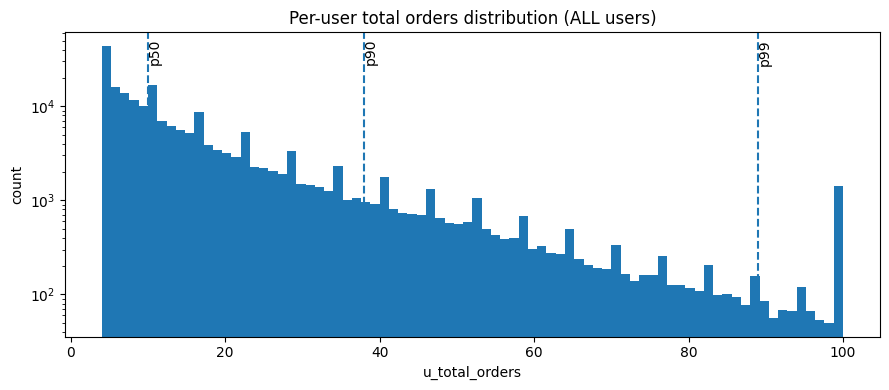


User coverage by minimum order threshold:
  users with >= 2 orders: 206209 (100.00%)
  users with >= 3 orders: 206209 (100.00%)
  users with >= 5 orders: 182223 (88.37%)
  users with >= 10 orders: 110728 (53.70%)
  users with >= 20 orders: 53931 (26.15%)
  users with >= 30 orders: 30677 (14.88%)

Filter: disabled for now; keep ALL users
  orders (all users): (3421083, 7)
  purchases op_all (all users): (33819106, 12)


In [39]:
u_total_orders = orders.groupby("user_id")["order_number"].max()
qs = plot_hist_with_quantiles(
    u_total_orders,
    title="Per-user total orders distribution (ALL users)",
    xlabel="u_total_orders",
    bins=80,
    logy=True,
)

# Threshold diagnostics: how much user coverage remains under different minimum-order cutoffs
print("\nUser coverage by minimum order threshold:")
for th in [2, 3, 5, 10, 20, 30]:
    kept = int((u_total_orders >= th).sum())
    print(f"  users with >= {th} orders: {kept} ({kept/u_total_orders.shape[0]:.2%})")

# Current choice: do not apply a minimum-order filter yet; keep all users for EDA
print("\nFilter: disabled for now; keep ALL users")
orders_f = orders.copy()
op_f = op_all.copy()
print("  orders (all users):", orders_f.shape)
print("  purchases op_all (all users):", op_f.shape)

# 7. Define a new target order and split purchases into target vs history

In [40]:
# For each user, find the maximum order_number among orders that appear in op_f.
user_last_avail = (
    op_f.groupby("user_id")["order_number"].max().rename("target_order_number").reset_index()
)

# Map that order_number back to a concrete target order_id (if ties exist, keep the max order_id)
target_orders = orders_f.merge(user_last_avail, on="user_id", how="inner")
target_orders = target_orders[target_orders["order_number"] == target_orders["target_order_number"]].copy()
target_orders = target_orders.sort_values(["user_id", "order_id"]).groupby("user_id").tail(1)

target_order_id_by_user = target_orders.set_index("user_id")["order_id"].to_dict()

print("\nNew target orders (last available with details) AFTER filtering:")
print("  users with a target order:", len(target_order_id_by_user))
print("  target orders eval_set breakdown:")
print(target_orders["eval_set"].value_counts(dropna=False))

# Split the unified purchase table into target-order rows vs history rows
user_target_series = pd.Series(target_order_id_by_user)
op_f = op_f.copy()
op_f["target_order_id"] = op_f["user_id"].map(user_target_series)
op_f["is_target_order"] = (op_f["order_id"] == op_f["target_order_id"])

target_op = op_f[op_f["is_target_order"]].copy()
history_op = op_f[~op_f["is_target_order"]].copy()

print("  target_op rows:", target_op.shape)
print("  history_op rows:", history_op.shape)

# Users eligible for supervised learning under this split (must have at least one history order)
user_hist_orders = history_op.groupby("user_id")["order_id"].nunique()
eligible_users = user_hist_orders[user_hist_orders >= 1].index
print("  users with >=1 history order:", int(eligible_users.shape[0]))


New target orders (last available with details) AFTER filtering:
  users with a target order: 206209
  target orders eval_set breakdown:
eval_set
train    131209
prior     75000
Name: count, dtype: int64
  target_op rows: (2165417, 14)
  history_op rows: (31653689, 14)
  users with >=1 history order: 206209


In [41]:
## -----------------------------------------------------
# Missing-value diagnostics (raw tables)
# Note: In Instacart, days_since_prior_order is NA for a user's first order.
## -----------------------------------------------------
print("\nMissing-value check (raw tables):")
print("  orders missing counts:")
print(orders.isna().sum().to_string())

# Focused check for the known NA pattern
na_days = int(orders["days_since_prior_order"].isna().sum())
first_orders = orders[orders["order_number"] == 1]
na_days_first = int(first_orders["days_since_prior_order"].isna().sum())
print("\n  days_since_prior_order NA count:", na_days)
print("  NA among first orders (order_number==1):", na_days_first)
print("  first orders total:", int(first_orders.shape[0]))

print("\n  prior missing counts:")
print(prior.isna().sum().to_string())
print("\n  train_op missing counts:")
print(train_op.isna().sum().to_string())

# For EDA convenience, treat first-order NA as 0 days since prior order
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)


Missing-value check (raw tables):
  orders missing counts:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209

  days_since_prior_order NA count: 206209
  NA among first orders (order_number==1): 206209
  first orders total: 206209

  prior missing counts:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0

  train_op missing counts:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0


# 8. Outlier inspection (no removal at this stage)

In [42]:
# We inspect extreme values in several key behavioral variables.
# At this stage, we do not remove any observations because most extremes reflect natural long-tail behavior rather than obvious data errors.

def print_outlier_summary(series: pd.Series, name: str):
    s = pd.Series(series).dropna().astype(float)
    q = s.quantile([0.50, 0.90, 0.95, 0.99, 0.999]).to_dict()
    print(f"\nOutlier inspection: {name}")
    print("  count:", int(s.shape[0]))
    print("  min/max:", float(s.min()), float(s.max()))
    print("  quantiles:", {k: float(v) for k, v in q.items()})

# 1) user total orders
print_outlier_summary(u_total_orders, "u_total_orders")

# 2) target basket size
bs_target_for_outlier = target_op.groupby("order_id")["product_id"].size()
print_outlier_summary(bs_target_for_outlier, "target basket size")

# 3) per-user unique products in history (candidate size)
h_u_unique_for_outlier = history_op.groupby("user_id")["product_id"].nunique()
print_outlier_summary(h_u_unique_for_outlier, "history unique products per user")

# 4) user-product purchase count
up_buy_cnt_for_outlier = history_op.groupby(["user_id", "product_id"])["order_id"].size()
print_outlier_summary(up_buy_cnt_for_outlier, "up_buy_cnt")

# 5) days_since_prior_order (note: this field is top-coded at 30 in the Instacart dataset)
days_since_series = orders_f["days_since_prior_order"]
print_outlier_summary(days_since_series, "days_since_prior_order")

print("\nOutlier treatment decision:")
print("  No outliers are removed at this stage.")
print("  Current interpretation: most extreme values reflect genuine long-tail user/product behavior, not obvious data errors.")
print("  We keep them for now and use quantiles / log-scale plots to describe them robustly.")


Outlier inspection: u_total_orders
  count: 206209
  min/max: 4.0 100.0
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.95: 52.0, 0.99: 89.0, 0.999: 100.0}

Outlier inspection: target basket size
  count: 206209
  min/max: 1.0 80.0
  quantiles: {0.5: 9.0, 0.9: 21.0, 0.95: 26.0, 0.99: 37.0, 0.999: 52.0}

Outlier inspection: history unique products per user
  count: 206209
  min/max: 1.0 726.0
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.95: 178.0, 0.99: 265.0, 0.999: 386.79200000001583}

Outlier inspection: up_buy_cnt
  count: 12984631
  min/max: 1.0 99.0
  quantiles: {0.5: 1.0, 0.9: 5.0, 0.95: 8.0, 0.99: 18.0, 0.999: 39.0}

Outlier inspection: days_since_prior_order
  count: 3214874
  min/max: 0.0 30.0
  quantiles: {0.5: 7.0, 0.9: 30.0, 0.95: 30.0, 0.99: 30.0, 0.999: 30.0}

Outlier treatment decision:
  No outliers are removed at this stage.
  Current interpretation: most extreme values reflect genuine long-tail user/product behavior, not obvious data errors.
  We keep them for now and use quantiles 

# 9. EDA based on the target/history split


Figure 2: Target order basket size summary
  mean=10.50, median=9.00, p90=21.00


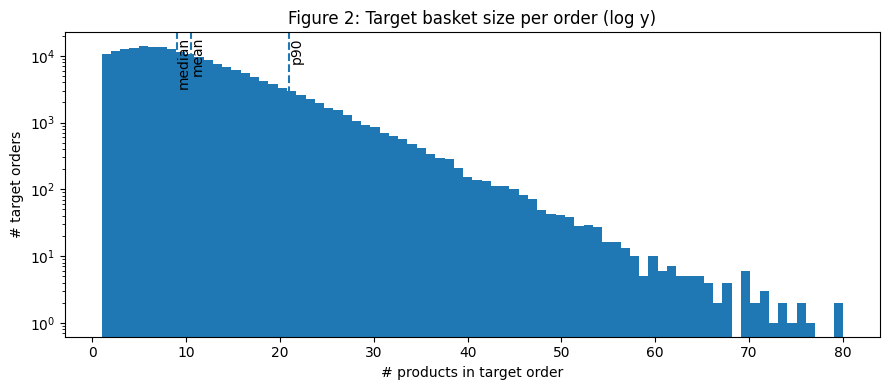

In [43]:
# 9.1 Figure 2: Target-order basket size distribution (supports Top-K choice)
# Basket size for each target order
bs_target = target_op.groupby("order_id")["product_id"].size().astype(float)
mean_bs = float(bs_target.mean())
median_bs = float(bs_target.median())
p90_bs = float(bs_target.quantile(0.90))

print("\nFigure 2: Target order basket size summary")
print(f"  mean={mean_bs:.2f}, median={median_bs:.2f}, p90={p90_bs:.2f}")

plt.figure(figsize=(9, 4))
plt.hist(bs_target.values, bins=80)
plt.yscale("log")
plt.axvline(mean_bs, linestyle="--")
plt.axvline(median_bs, linestyle="--")
plt.axvline(p90_bs, linestyle="--")

# Add simple reference labels
ymax = plt.ylim()[1]
plt.text(mean_bs, ymax * 0.85, "mean", rotation=90, va="top")
plt.text(median_bs, ymax * 0.85, "median", rotation=90, va="top")
plt.text(p90_bs, ymax * 0.85, "p90", rotation=90, va="top")

plt.title("Figure 2: Target basket size per order (log y)")
plt.xlabel("# products in target order")
plt.ylabel("# target orders")
plt.tight_layout()
plt.show()



Figure 3: Per-user unique products in HISTORY (candidate size)
  count: 206209
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.99: 265.0}


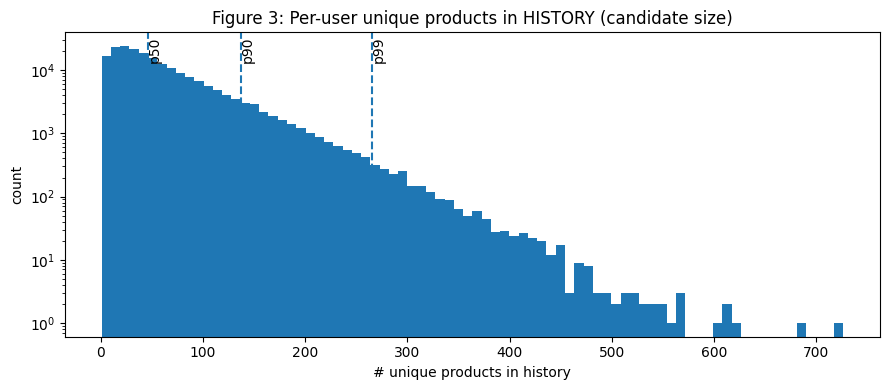


Figure 4: up_buy_cnt tail
  #(user,product) pairs with up_buy_cnt > 20: 98648


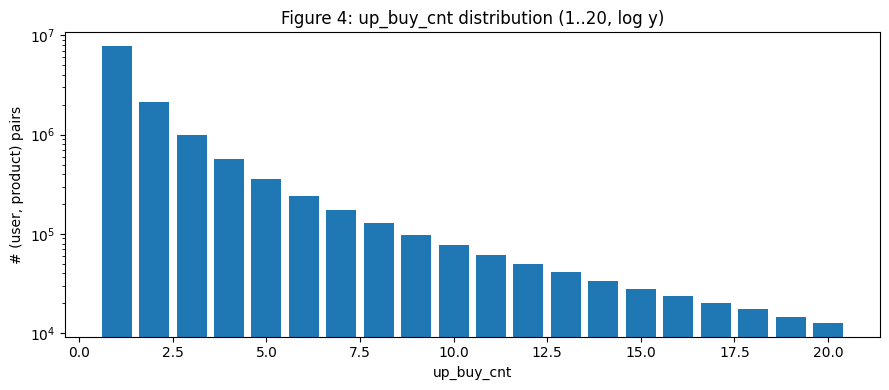

In [44]:
# 9.2 Figure 3: Candidate size per user in history (unique products)
h_u_unique = history_op.groupby("user_id")["product_id"].nunique()
plot_hist_with_quantiles(
    h_u_unique,
    title="Figure 3: Per-user unique products in HISTORY (candidate size)",
    xlabel="# unique products in history",
    bins=80,
    logy=True,
)

# 9.3 Figure 4: User-product purchase frequency distribution (up_buy_cnt)
up_buy_cnt = history_op.groupby(["user_id", "product_id"])["order_id"].size()
vc = up_buy_cnt.value_counts()
xs = list(range(1, 21))
ys = [int(vc.get(i, 0)) for i in xs]
ys_tail = int(vc[vc.index > 20].sum()) if (vc.index > 20).any() else 0

print("\nFigure 4: up_buy_cnt tail")
print("  #(user,product) pairs with up_buy_cnt > 20:", ys_tail)

plt.figure(figsize=(9, 4))
plt.bar(xs, ys)
plt.yscale("log")
plt.title("Figure 4: up_buy_cnt distribution (1..20, log y)")
plt.xlabel("up_buy_cnt")
plt.ylabel("# (user, product) pairs")
plt.tight_layout()
plt.show()



Figure 5: orders_since_last bins vs purchase probability
  bin  purchase_prob  n_pairs
    0            NaN        0
    1       0.279874  2129254
    2       0.162327  1516840
    3       0.111672  1207987
    4       0.083610   947765
    5       0.067328   770413
 6-10       0.044943  2423681
11-20       0.023686  2071035
  >20       0.010514  1917656


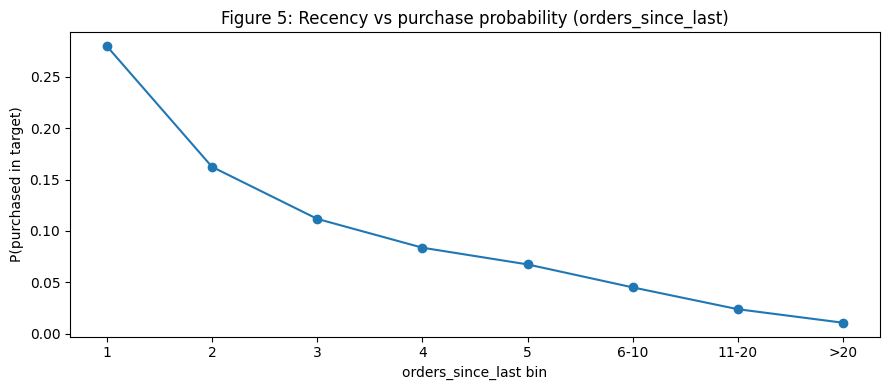

In [45]:
# 9.4 Figure 5: Recency vs purchase probability
# Build the binary label: whether a (user, product) pair appears in the target order
label_df = target_op[["user_id", "product_id"]].drop_duplicates().copy()
label_df["label"] = 1

# For each (user, product) pair in history, compute the last observed order_number
up_last = (
    history_op.groupby(["user_id", "product_id"])["order_number"].max().rename("up_last_order").reset_index()
)

# Target order_number for each user
user_target_on = target_orders[["user_id", "target_order_number"]].copy()

rec = up_last.merge(user_target_on, on="user_id", how="left")
rec["orders_since_last"] = (rec["target_order_number"] - rec["up_last_order"]).astype(float)

# Attach the binary label
rec = rec.merge(label_df, on=["user_id", "product_id"], how="left")
rec["label"] = rec["label"].fillna(0).astype(int)

# Bucket orders_since_last into interpretable bins
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, 1e9]
labels = ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
rec["bin"] = pd.cut(rec["orders_since_last"], bins=bins, labels=labels)

agg = rec.groupby("bin").agg(
    purchase_prob=("label", "mean"),
    n_pairs=("label", "size"),
).reset_index()

print("\nFigure 5: orders_since_last bins vs purchase probability")
print(agg.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.plot(agg["bin"].astype(str), agg["purchase_prob"], marker="o")
plt.title("Figure 5: Recency vs purchase probability (orders_since_last)")
plt.xlabel("orders_since_last bin")
plt.ylabel("P(purchased in target)")
plt.tight_layout()
plt.show()


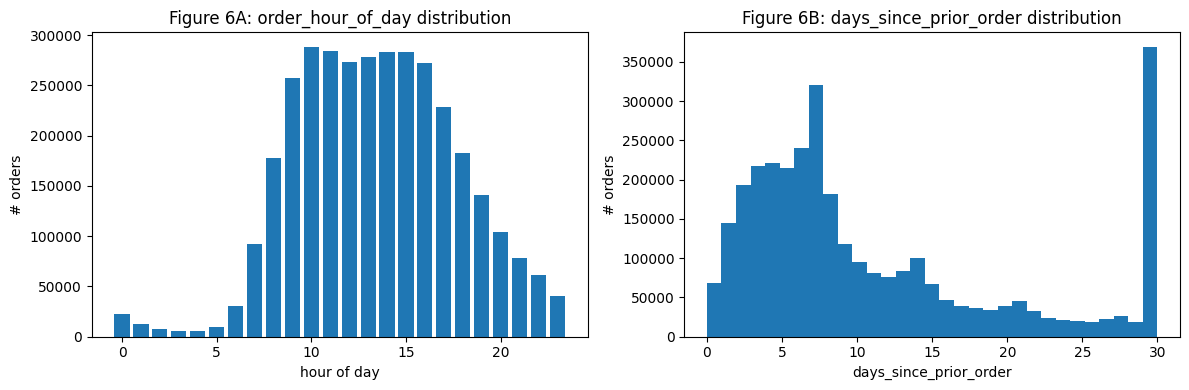


Figure 6: Temporal behavior summary
  order_hour_of_day top 5 hours:
order_hour_of_day
10    288418
11    284728
15    283639
14    283042
13    277999
  days_since_prior_order quantiles: {0.5: 7.0, 0.9: 30.0, 0.99: 30.0}


In [46]:
# 9.5 Figure 6: Temporal ordering behavior
# Use orders_f to show when users place orders and how long they wait between orders.
orders_time = orders_f.copy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
hour_counts = orders_time["order_hour_of_day"].value_counts().sort_index()
plt.bar(hour_counts.index.astype(int), hour_counts.values)
plt.title("Figure 6A: order_hour_of_day distribution")
plt.xlabel("hour of day")
plt.ylabel("# orders")

plt.subplot(1, 2, 2)
plt.hist(orders_time["days_since_prior_order"].values, bins=31)
plt.title("Figure 6B: days_since_prior_order distribution")
plt.xlabel("days_since_prior_order")
plt.ylabel("# orders")

plt.tight_layout()
plt.show()

print("\nFigure 6: Temporal behavior summary")
print("  order_hour_of_day top 5 hours:")
print(hour_counts.sort_values(ascending=False).head(5).to_string())
print("  days_since_prior_order quantiles:", orders_time["days_since_prior_order"].quantile([0.5, 0.9, 0.99]).to_dict())



Figure 7: Product-level summary
  p_total_purchases quantiles: {0.5: 58.0, 0.9: 995.3000000000029, 0.99: 9694.57000000005}
  p_reorder_ratio quantiles: {0.5: 0.3758035719546759, 0.9: 0.6348245809062211, 0.99: 0.7754083529138885}


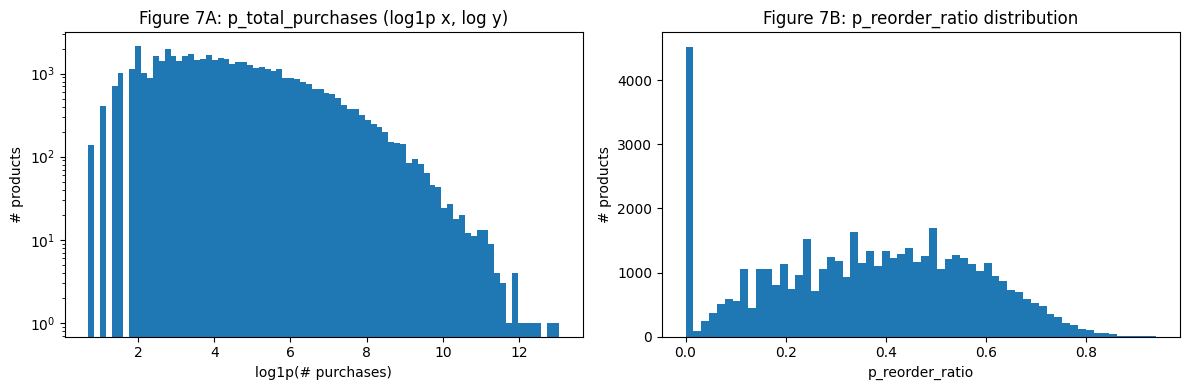

In [47]:
# 9.6 Figure 7: Product-level popularity and reorder behavior
# Use history_op so the EDA matches the future feature-building data source.
p_total_purchases = history_op.groupby("product_id")["order_id"].size().astype(float)
p_reorder_ratio = history_op.groupby("product_id")["reordered"].mean().astype(float)

print("\nFigure 7: Product-level summary")
print("  p_total_purchases quantiles:", p_total_purchases.quantile([0.5, 0.9, 0.99]).to_dict())
print("  p_reorder_ratio quantiles:", p_reorder_ratio.quantile([0.5, 0.9, 0.99]).to_dict())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(p_total_purchases.values), bins=80)
plt.yscale("log")
plt.title("Figure 7A: p_total_purchases (log1p x, log y)")
plt.xlabel("log1p(# purchases)")
plt.ylabel("# products")

plt.subplot(1, 2, 2)
plt.hist(p_reorder_ratio.values, bins=60)
plt.title("Figure 7B: p_reorder_ratio distribution")
plt.xlabel("p_reorder_ratio")
plt.ylabel("# products")

plt.tight_layout()
plt.show()


# 10. Department-level analysis


Department summary table
 department_id      department  purchase_count  unique_users  reorder_ratio
             4         produce         9251194        192360       0.649857
            16      dairy eggs         5291436        189420       0.670065
            19          snacks         2819848        172125       0.574232
             7       beverages         2625872        170793       0.653531
             1          frozen         2179574        161064       0.541748
            13          pantry         1829552        170412       0.346842
             3          bakery         1149453        138454       0.628229
            15    canned goods         1040703        131466       0.457325
            20            deli         1026201        131634       0.607681
             9 dry goods pasta          844413        122656       0.460738
            17       household          718705        109508       0.402219
            14       breakfast          692737        111982  

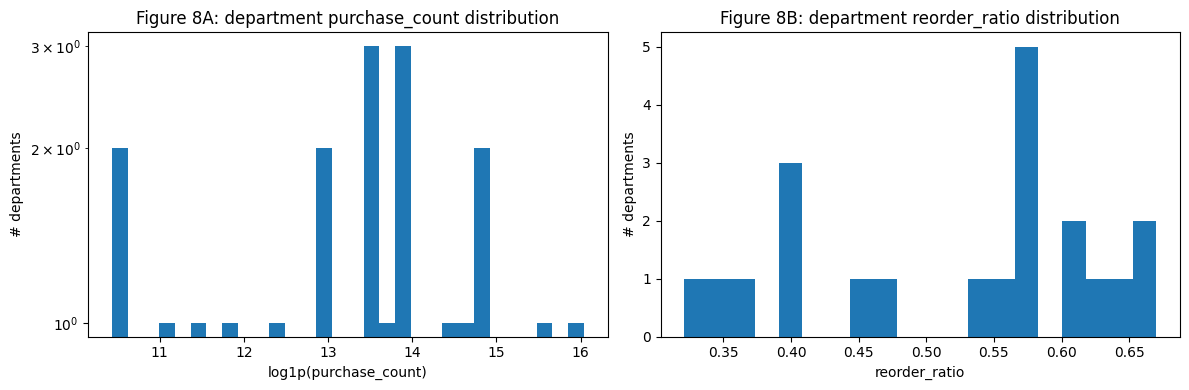

In [48]:
# history_op already inherits aisle/department metadata from op_all
hist_meta = history_op.copy()
# Aggregate summary at the department level
dep_summary = hist_meta.groupby(["department_id", "department"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

dep_summary = dep_summary.sort_values("purchase_count", ascending=False)

print("\nDepartment summary table")
print(dep_summary.to_string(index=False))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(dep_summary["purchase_count"].values.astype(float)), bins=30)
plt.yscale("log")
plt.title("Figure 8A: department purchase_count distribution")
plt.xlabel("log1p(purchase_count)")
plt.ylabel("# departments")

plt.subplot(1, 2, 2)
plt.hist(dep_summary["reorder_ratio"].values.astype(float), bins=20)
plt.title("Figure 8B: department reorder_ratio distribution")
plt.xlabel("reorder_ratio")
plt.ylabel("# departments")

plt.tight_layout()
plt.show()


# 11. Aisle-level analysis


Top 15 aisles by purchase_count
 aisle_id                         aisle  purchase_count  unique_users  reorder_ratio
       24                  fresh fruits         3557919        175507       0.717928
       83              fresh vegetables         3334155        157589       0.594549
      123    packaged vegetables fruits         1721845        157201       0.638393
      120                        yogurt         1420890        122489       0.686725
       21               packaged cheese          956311        130790       0.585290
       84                          milk          872161        107495       0.781403
      115 water seltzer sparkling water          821333         97987       0.729461
      107                chips pretzels          704570        109817       0.588806
       91               soy lactosefree          623627         94673       0.692526
      112                         bread          571553        101699       0.670199
       31                  refri

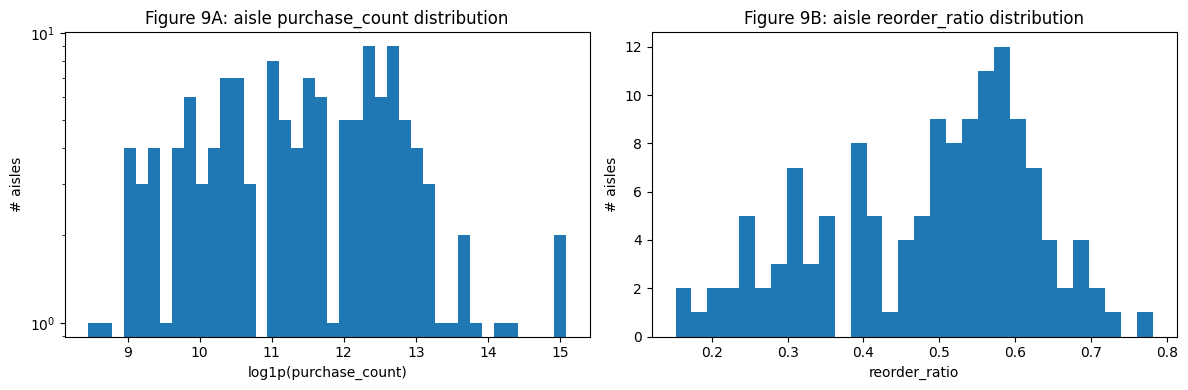

In [49]:
aisle_summary = hist_meta.groupby(["aisle_id", "aisle"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

aisle_summary = aisle_summary.sort_values("purchase_count", ascending=False)

print("\nTop 15 aisles by purchase_count")
print(aisle_summary.head(15).to_string(index=False))

MIN_CNT = 1000
print(f"\nTop 15 aisles by reorder_ratio (purchase_count >= {MIN_CNT})")
print(
    aisle_summary[aisle_summary["purchase_count"] >= MIN_CNT]
    .sort_values("reorder_ratio", ascending=False)
    .head(15)
    .to_string(index=False)
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(aisle_summary["purchase_count"].values.astype(float)), bins=40)
plt.yscale("log")
plt.title("Figure 9A: aisle purchase_count distribution")
plt.xlabel("log1p(purchase_count)")
plt.ylabel("# aisles")

plt.subplot(1, 2, 2)
plt.hist(aisle_summary["reorder_ratio"].values.astype(float), bins=30)
plt.title("Figure 9B: aisle reorder_ratio distribution")
plt.xlabel("reorder_ratio")
plt.ylabel("# aisles")

plt.tight_layout()
plt.show()
